In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/Colab Notebooks/merged_claims.csv'

df = pd.read_csv(file_path)
print(df.head())

  InsuID InsuPlanID   Diag1  Diag2   Diag3  Diag4   Diag5   Diag6 Diag7  \
0     81      NY283     I10  E78.5   E11.9  R07.9     R42  R06.09   NaN   
1    130      NY353  R94.31  R07.9  R06.02    R42  R26.89     R55   I10   
2    NY1        NY1   B35.3  B35.1     NaN    NaN     NaN     NaN   NaN   
3     13          3     I10  E11.9   R53.1    NaN     NaN     NaN   NaN   
4  NY101        NaN  H52.13    NaN     NaN    NaN     NaN     NaN   NaN   

   Diag8  ... Paid6 Proc6_Adj Claim_status GeneralRemark Remark1 Remark2  \
0    NaN  ...   NaN       NaN            1           NaN     NaN     NaN   
1  E78.5  ...   NaN       NaN            1           NaN     NaN     NaN   
2    NaN  ...   NaN       NaN            1           NaN     NaN     NaN   
3    NaN  ...   NaN       NaN            1           NaN     NaN     NaN   
4    NaN  ...   NaN       NaN            1           NaN     NaN     NaN   

  Remark3 Remark4 Remark5 Remark6  
0     NaN     NaN     NaN     NaN  
1     NaN     NaN   

/tmp/ipython-input-3802110649.py:5: DtypeWarning: Columns (16,17,20,21,24,25,28,29,32,33,36,37,39,40,41,42,43,44,45) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


In [ ]:
print(df.columns.tolist())


['InsuID', 'InsuPlanID', 'Diag1', 'Diag2', 'Diag3', 'Diag4', 'Diag5', 'Diag6', 'Diag7', 'Diag8', 'Diag9', 'Diag10', 'Diag11', 'Diag12', 'Proc1', 'Modifier1', 'Paid1', 'Proc1_Adj', 'Proc2', 'Modifier2', 'Paid2', 'Proc2_Adj', 'Proc3', 'Modifier3', 'Paid3', 'Proc3_Adj', 'Proc4', 'Modifier4', 'Paid4', 'Proc4_Adj', 'Proc5', 'Modifier5', 'Paid5', 'Proc5_Adj', 'Proc6', 'Modifier6', 'Paid6', 'Proc6_Adj', 'Claim_status', 'GeneralRemark', 'Remark1', 'Remark2', 'Remark3', 'Remark4', 'Remark5', 'Remark6']


In [ ]:

cols_to_drop = ["GeneralRemark"] + [f"Remark{i}" for i in range(1, 7)]
df.drop(columns=[col for col in cols_to_drop if col in df.columns], inplace=True)

print("Dropped columns:", [col for col in cols_to_drop if col not in df.columns])
print("Remaining columns:", df.columns.tolist()[:20])
print("Data shape after drop:", df.shape)




Dropped columns: ['GeneralRemark', 'Remark1', 'Remark2', 'Remark3', 'Remark4', 'Remark5', 'Remark6']
Remaining columns: ['InsuID', 'InsuPlanID', 'Diag1', 'Diag2', 'Diag3', 'Diag4', 'Diag5', 'Diag6', 'Diag7', 'Diag8', 'Diag9', 'Diag10', 'Diag11', 'Diag12', 'Proc1', 'Modifier1', 'Paid1', 'Proc1_Adj', 'Proc2', 'Modifier2']
Data shape after drop: (39802, 39)


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39802 entries, 0 to 39801
Data columns (total 39 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   InsuID        39800 non-null  object
 1   InsuPlanID    33944 non-null  object
 2   Diag1         39797 non-null  object
 3   Diag2         33746 non-null  object
 4   Diag3         28627 non-null  object
 5   Diag4         21938 non-null  object
 6   Diag5         15443 non-null  object
 7   Diag6         10809 non-null  object
 8   Diag7         8025 non-null   object
 9   Diag8         5836 non-null   object
 10  Diag9         4320 non-null   object
 11  Diag10        3001 non-null   object
 12  Diag11        2075 non-null   object
 13  Diag12        1254 non-null   object
 14  Proc1         39802 non-null  object
 15  Modifier1     17233 non-null  object
 16  Paid1         39802 non-null  object
 17  Proc1_Adj     19597 non-null  object
 18  Proc2         23680 non-null  object
 19  Modi

In [ ]:
df.to_csv("cleaned_claims.csv", index=False)

print(" Data saved successfully to cleaned_claims.csv")


 Data saved successfully to cleaned_claims.csv


In [ ]:
# df = df.replace('', pd.NA)

In [ ]:
df.isna().sum()

,0
InsuID,2
InsuPlanID,5858
Diag1,5
Diag2,6056
Diag3,11175
Diag4,17864
Diag5,24359
Diag6,28993
Diag7,31777
Diag8,33966


In [ ]:
print("New shape:", df.shape)

New shape: (39802, 39)


In [ ]:
before = df.shape[0]
df.drop_duplicates(inplace=True)
after = df.shape[0]

print(f"Removed {before - after} duplicate rows.")
print("Data shape after removing duplicates:", df.shape)


Removed 2324 duplicate rows.
Data shape after removing duplicates: (37478, 39)


In [ ]:
# df = df.dropna()
# print("New shape:", df.shape)

Dataset shape: (37478, 39)

Column-wise Non-Null Count:
<class 'pandas.core.frame.DataFrame'>
Index: 37478 entries, 0 to 39801
Data columns (total 39 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   InsuID        37476 non-null  object
 1   InsuPlanID    32274 non-null  object
 2   Diag1         37474 non-null  object
 3   Diag2         32884 non-null  object
 4   Diag3         28156 non-null  object
 5   Diag4         21740 non-null  object
 6   Diag5         15367 non-null  object
 7   Diag6         10752 non-null  object
 8   Diag7         7984 non-null   object
 9   Diag8         5812 non-null   object
 10  Diag9         4301 non-null   object
 11  Diag10        2996 non-null   object
 12  Diag11        2074 non-null   object
 13  Diag12        1254 non-null   object
 14  Proc1         37478 non-null  object
 15  Modifier1     15887 non-null  object
 16  Paid1         37478 non-null  object
 17  Proc1_Adj     19578 non-null  object


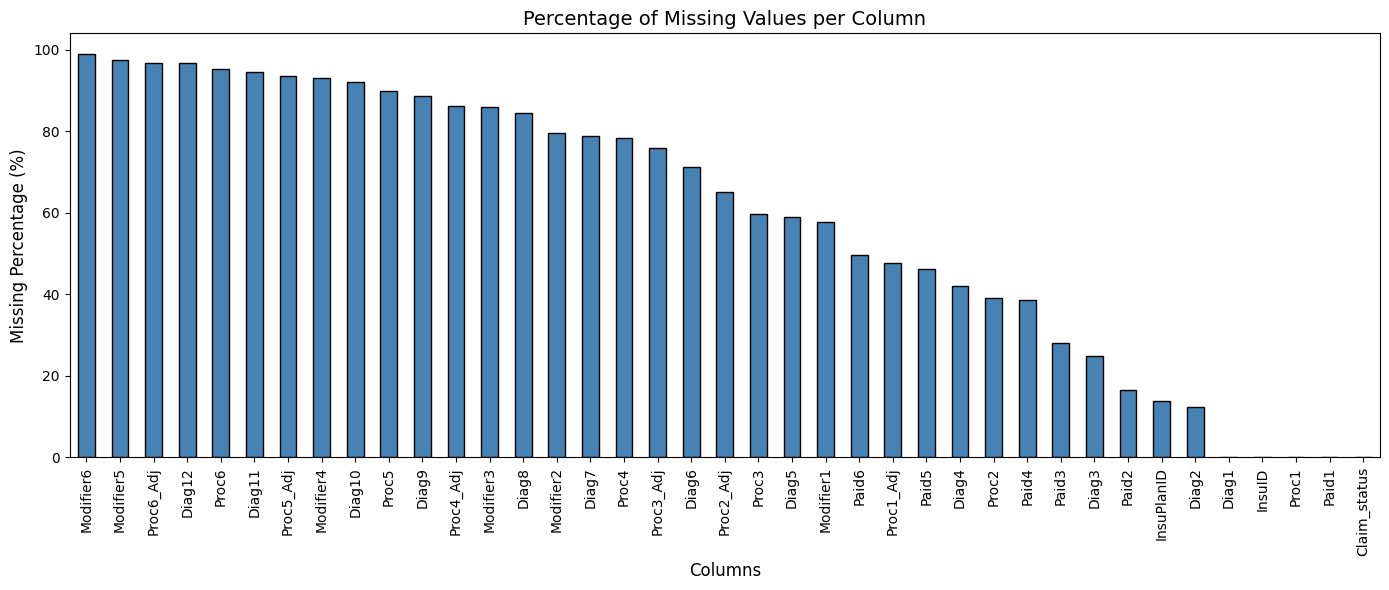

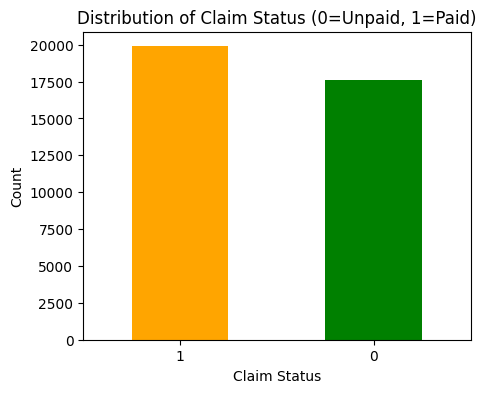

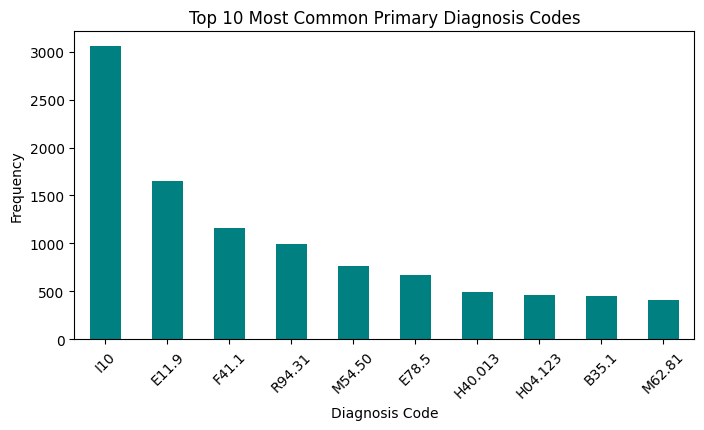

In [ ]:
import matplotlib.pyplot as plt


print("Dataset shape:", df.shape)
print("\nColumn-wise Non-Null Count:")
print(df.info())

missing_percent = df.isna().mean() * 100
missing_percent = missing_percent.sort_values(ascending=False)

print("\n=== Missing Values Percentage by Column ===")
print(missing_percent)

high_missing_cols = missing_percent[missing_percent > 80].index.tolist()

print("\n=== Columns with more than 80% missing values ===")
print(high_missing_cols)
print(f"\nTotal columns with >80% missing: {len(high_missing_cols)}")


plt.figure(figsize=(14,6))
missing_percent.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title("Percentage of Missing Values per Column", fontsize=14)
plt.xlabel("Columns", fontsize=12)
plt.ylabel("Missing Percentage (%)", fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


categorical_cols = df.select_dtypes(include='object').columns.tolist()
numeric_cols = df.select_dtypes(exclude='object').columns.tolist()

plt.figure(figsize=(5,4))
df['Claim_status'].value_counts().plot(kind='bar', color=['orange','green'])
plt.title("Distribution of Claim Status (0=Unpaid, 1=Paid)")
plt.xlabel("Claim Status")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

if 'Diag1' in df.columns:
    plt.figure(figsize=(8,4))
    df['Diag1'].value_counts().head(10).plot(kind='bar', color='teal')
    plt.title("Top 10 Most Common Primary Diagnosis Codes")
    plt.xlabel("Diagnosis Code")
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)
    plt.show()


In [ ]:
import pandas as pd
import numpy as np

# Identify Paid columns
paid_cols = [f"Paid{i}" for i in range(1, 7)]
paid_cols = [col for col in paid_cols if col in df.columns]

# Standardize text (lowercase, remove spaces)
df[paid_cols] = df[paid_cols].apply(lambda col: col.astype(str).str.strip().str.lower())

# Replace text values with numeric
df[paid_cols] = df[paid_cols].replace({
    'paid': 1,
    'not paid': 0,
    '0': 0,
    '': 0,
    'nan': 0
})

# Convert all to numeric, replace invalid with 0
df[paid_cols] = df[paid_cols].apply(pd.to_numeric, errors='coerce').fillna(0).astype(int)

df[paid_cols] = df[paid_cols].applymap(lambda x: 0 if x <= 0 else 1)

# Print sample results
print("Cleaned Paid columns:")
print(df[paid_cols].head(10))


Cleaned Paid columns:
   Paid1  Paid2  Paid3  Paid4  Paid5  Paid6
0      1      0      0      0      0      0
1      1      1      1      1      0      0
2      1      0      0      0      0      0
3      1      1      1      0      0      0
4      0      1      1      1      0      0
5      1      1      1      1      1      0
6      1      1      0      0      0      0
7      1      0      0      0      0      0
8      1      0      0      0      0      0
9      1      0      0      0      0      0


/tmp/ipython-input-1972501545.py:23: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[paid_cols] = df[paid_cols].applymap(lambda x: 0 if x <= 0 else 1)


In [ ]:
df.to_csv("cleaned_after_converting_paid_claims_to_zero_one.csv", index=False)

print(" Data saved successfully to cleaned_after_converting_paid_claims_to_zero_one.csv")


 Data saved successfully to cleaned_after_converting_paid_claims_to_zero_one.csv


In [ ]:
# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(exclude=['object']).columns.tolist()

print("Categorical columns:")
print(categorical_cols)
print("\nNumerical columns:")
print(numerical_cols)


Categorical columns:
['InsuID', 'InsuPlanID', 'Diag1', 'Diag2', 'Diag3', 'Diag4', 'Diag5', 'Diag6', 'Diag7', 'Diag8', 'Diag9', 'Diag10', 'Diag11', 'Diag12', 'Proc1', 'Modifier1', 'Proc1_Adj', 'Proc2', 'Modifier2', 'Proc2_Adj', 'Proc3', 'Modifier3', 'Proc3_Adj', 'Proc4', 'Modifier4', 'Proc4_Adj', 'Proc5', 'Modifier5', 'Proc5_Adj', 'Proc6', 'Modifier6', 'Proc6_Adj']

Numerical columns:
['Paid1', 'Paid2', 'Paid3', 'Paid4', 'Paid5', 'Paid6', 'Claim_status']


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Columns to exclude from encoding
exclude_cols = ['Claim_status', 'paid1', 'paid2', 'paid3', 'paid4', 'paid5', 'paid6']

# Select categorical columns
categorical_cols = [col for col in df.columns if col not in exclude_cols]

# Apply LabelEncoder to categorical columns
encoder = LabelEncoder()
for col in categorical_cols:
    df[col] = df[col].astype(str).fillna("None")
    df[col] = encoder.fit_transform(df[col])

print("Label encoding applied on categorical columns.")
print("Encoded columns sample:", categorical_cols[:20])
print("Data shape:", df.shape)


Label encoding applied on categorical columns.
Encoded columns sample: ['InsuID', 'InsuPlanID', 'Diag1', 'Diag2', 'Diag3', 'Diag4', 'Diag5', 'Diag6', 'Diag7', 'Diag8', 'Diag9', 'Diag10', 'Diag11', 'Diag12', 'Proc1', 'Modifier1', 'Paid1', 'Proc1_Adj', 'Proc2', 'Modifier2']
Data shape: (37478, 39)


In [ ]:
df.to_csv("after_label_encoding.csv", index=False)

print(" Data saved successfully to after_label_encoding.csv")


 Data saved successfully to after_label_encoding.csv


In [ ]:
# MinMax Scaling (0 to 1) on categorical columns

from sklearn.preprocessing import MinMaxScaler

# Columns to exclude from scaling
exclude_cols = ['Claim_status', 'paid1', 'paid2', 'paid3', 'paid4', 'paid5', 'paid6']

# Columns that were label-encoded (categorical ones)
categorical_cols = [col for col in df.columns if col not in exclude_cols]

# Initialize scaler
scaler = MinMaxScaler(feature_range=(0, 1))

# Fit and transform the categorical columns
df[categorical_cols] = scaler.fit_transform(df[categorical_cols])

print(" MinMax scaling applied (0 to 1 range).")
print(df.head(5))

 MinMax scaling applied (0 to 1 range).
     InsuID  InsuPlanID     Diag1     Diag2     Diag3     Diag4     Diag5  \
0  0.177083    0.510067  0.397455  0.112004  0.091141  0.774302  0.820225   
1  0.036458    0.644295  0.896692  0.778503  0.764257  0.832402  0.797092   
2  0.208333    0.120805  0.021374  0.015570  1.000000  1.000000  1.000000   
3  0.031250    0.026846  0.397455  0.089905  0.835031  1.000000  1.000000   
4  0.213542    1.000000  0.367430  1.000000  1.000000  1.000000  1.000000   

      Diag6     Diag7     Diag8  ...  Proc4_Adj  Proc5  Modifier5  Paid5  \
0  0.742331  1.000000  1.000000  ...   1.000000    1.0        1.0    0.0   
1  0.825920  0.330695  0.107492  ...   0.485075    1.0        1.0    0.0   
2  1.000000  1.000000  1.000000  ...   1.000000    1.0        1.0    0.0   
3  1.000000  1.000000  1.000000  ...   1.000000    1.0        1.0    0.0   
4  1.000000  1.000000  1.000000  ...   0.485075    1.0        1.0    0.0   

   Proc5_Adj  Proc6  Modifier6  Paid6  P

In [ ]:
df.to_csv("after_standard_scaling.csv", index=False)

print(" Data saved successfully to after_standard_scaling.csv")


 Data saved successfully to after_standard_scaling.csv


In [ ]:
!pip install lightgbm


In [ ]:
import pandas as pd

X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv')
y_test = pd.read_csv('y_test.csv')


In [ ]:
# finds columns where each unique value maps to a single class (strong leakage)
leaky_cols = []
for c in train_df.columns.drop('Claim_status'):
    mapping = train_df.groupby(c)['Claim_status'].nunique()
    if (mapping == 1).any():
        leaky_cols.append(c)

print("Potentially leaky columns (some value maps to single class):", leaky_cols)


Potentially leaky columns (some value maps to single class): ['InsuID', 'InsuPlanID', 'Diag1', 'Diag2', 'Diag3', 'Diag4', 'Diag5', 'Diag6', 'Diag7', 'Diag8', 'Diag9', 'Diag10', 'Diag11', 'Diag12', 'Proc1', 'Modifier1', 'Paid1', 'Proc1_Adj', 'Proc2', 'Modifier2', 'Paid2', 'Proc2_Adj', 'Proc3', 'Modifier3', 'Paid3', 'Proc3_Adj', 'Proc4', 'Modifier4', 'Paid4', 'Proc4_Adj', 'Proc5', 'Modifier5', 'Paid5', 'Proc5_Adj', 'Proc6', 'Modifier6', 'Paid6', 'Proc6_Adj']


In [ ]:
# Drop highly correlated features with target
corr_with_target = df.corr(numeric_only=True)['Claim_status'].abs()
high_corr_features = corr_with_target[corr_with_target > 0.9].index.tolist()

# Exclude the target itself
high_corr_features = [f for f in high_corr_features if f != 'Claim_status']

print("Highly correlated features to drop:", high_corr_features)

# Drop them
df_clean = df.drop(columns=high_corr_features)


Highly correlated features to drop: ['Paid1', 'Proc1_Adj']


In [ ]:
import lightgbm as lgb


X = df_clean.drop('Claim_status', axis=1)
y = df_clean['Claim_status']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = lgb.LGBMClassifier(
    objective='binary',
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

callbacks = [lgb.early_stopping(stopping_rounds=50)]
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], eval_metric='accuracy', callbacks=callbacks)

y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


[LightGBM] [Info] Number of positive: 15905, number of negative: 14077
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007929 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5045
[LightGBM] [Info] Number of data points in the train set: 29982, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.530485 -> initscore=0.122091
[LightGBM] [Info] Start training from score 0.122091
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[473]	valid_0's binary_logloss: 0.201091
Accuracy: 0.9051494130202775

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.92      0.90      3519
           1       0.93      0.89      0.91      3977

    accuracy                           0.91      7496
   macro avg       0.9

In [ ]:
# Save splits
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

print(" Train/Test split saved as CSV files.")


 Train/Test split saved as CSV files.


In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve


# --- AUC Calculation ---
try:
    # For binary classification — use predicted probabilities if available
    if 'predict_proba' in dir(model):
        y_prob = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
    else:
        # fallback: use y_pred (only works if binary)
        auc = roc_auc_score(y_test, y_pred)
    print("\nAUC (Area Under Curve):", auc)
except Exception as e:
    print("\n Could not compute AUC:", e)



AUC (Area Under Curve): 0.9738838617589646


In [ ]:
import joblib

joblib.dump(model, "claim_status_lightgbm_model.pkl")

print(" Model saved successfully as 'claim_status_model.pkl'")


 Model saved successfully as 'claim_status_model.pkl'


/tmp/ipython-input-1878519163.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Claim_status', data=train_df, palette='coolwarm', ax=axes[0])
/tmp/ipython-input-1878519163.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Claim_status', data=test_df, palette='coolwarm', ax=axes[1])


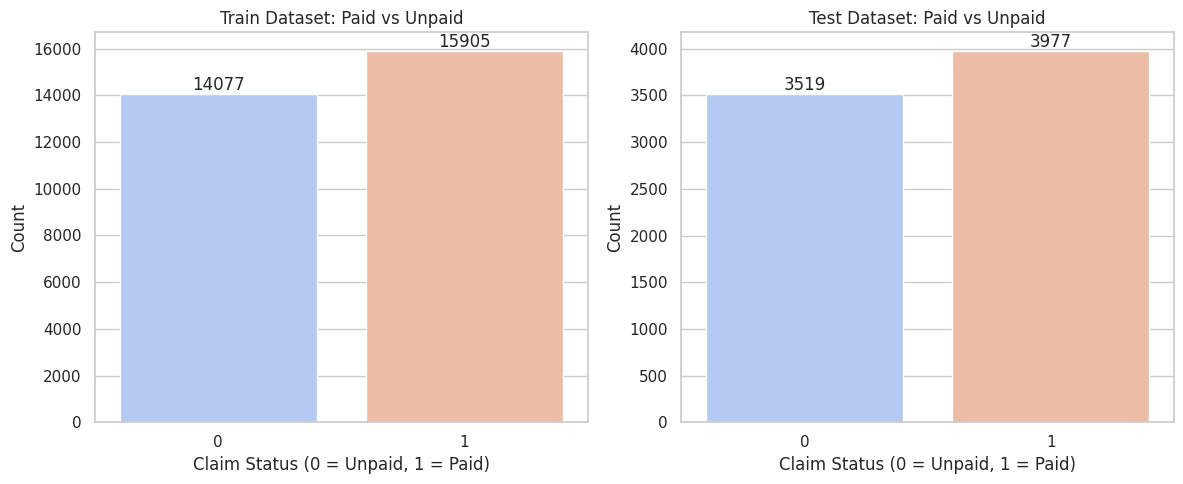

 Saved: train_test_distribution.png


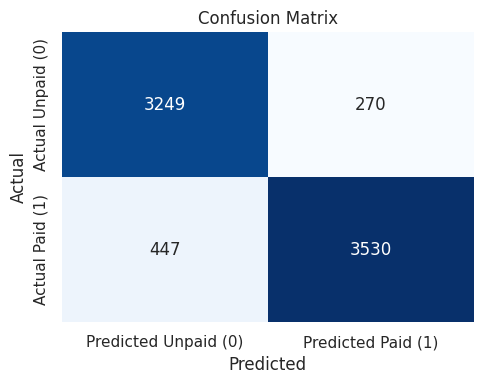

 Saved: confusion_matrix.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix

# Combine y_train and y_test into DataFrames
train_df = pd.DataFrame({'Claim_status': y_train})
test_df = pd.DataFrame({'Claim_status': y_test})

sns.set(style="whitegrid")

# ---- 1 Distribution Graphs ----
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x='Claim_status', data=train_df, palette='coolwarm', ax=axes[0])
axes[0].set_title('Train Dataset: Paid vs Unpaid')
axes[0].set_xlabel('Claim Status (0 = Unpaid, 1 = Paid)')
axes[0].set_ylabel('Count')

for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom')

sns.countplot(x='Claim_status', data=test_df, palette='coolwarm', ax=axes[1])
axes[1].set_title('Test Dataset: Paid vs Unpaid')
axes[1].set_xlabel('Claim Status (0 = Unpaid, 1 = Paid)')
axes[1].set_ylabel('Count')

for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom')

plt.tight_layout()
plt.savefig('train_test_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Saved: train_test_distribution.png")

# ---- 2 Confusion Matrix ----
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Unpaid (0)', 'Predicted Paid (1)'],
            yticklabels=['Actual Unpaid (0)', 'Actual Paid (1)'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Saved: confusion_matrix.png")


In [ ]:
!pip install xgboost


In [ ]:
import pandas as pd

X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv')
y_test = pd.read_csv('y_test.csv')


Training XGBoost model...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [18:06:48] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Model Evaluation Results:

Accuracy: 0.9043489861259338

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.92      0.90      3519
           1       0.93      0.89      0.91      3977

    accuracy                           0.90      7496
   macro avg       0.90      0.91      0.90      7496
weighted avg       0.91      0.90      0.90      7496


Confusion Matrix:
 [[3249  270]
 [ 447 3530]]

AUC (Area Under Curve): 0.9734661430248652


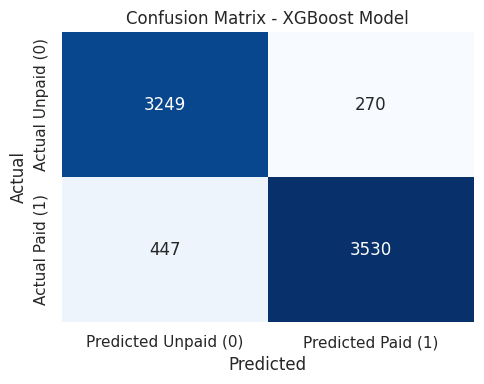

 Confusion matrix saved as 'confusion_matrix_xgboost.png'


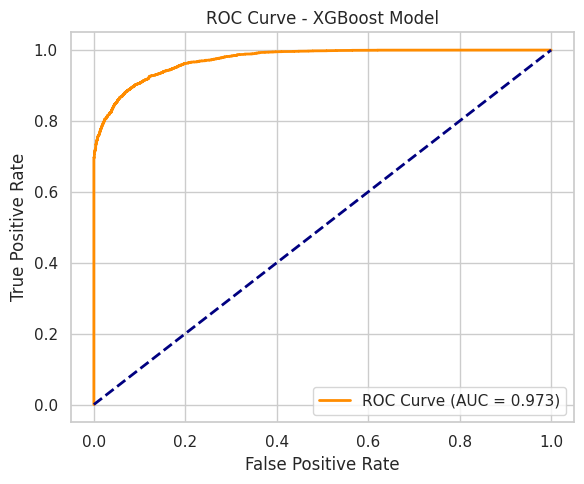

 ROC curve saved as 'roc_curve_xgboost.png'

 Model saved successfully as 'xgboost_claim_model.pkl'


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
from xgboost import XGBClassifier
import joblib
import seaborn as sns
import matplotlib.pyplot as plt


# --- Step 4: Train XGBoost model ---
model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

print("Training XGBoost model...")
model.fit(X_train, y_train)

# --- Step 5: Predictions ---
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# --- Step 6: Evaluation ---
print("\nModel Evaluation Results:\n")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nAUC (Area Under Curve):", roc_auc_score(y_test, y_prob))

# --- Step 7: Confusion Matrix Visualization ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Unpaid (0)', 'Predicted Paid (1)'],
            yticklabels=['Actual Unpaid (0)', 'Actual Paid (1)'])
plt.title('Confusion Matrix - XGBoost Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig("confusion_matrix_xgboost.png", dpi=300, bbox_inches="tight")
plt.show()
print(" Confusion matrix saved as 'confusion_matrix_xgboost.png'")

# --- Step 8: ROC Curve Visualization ---
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost Model')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("roc_curve_xgboost.png", dpi=300, bbox_inches="tight")
plt.show()
print(" ROC curve saved as 'roc_curve_xgboost.png'")

# --- Step 9: Save model ---
joblib.dump(model, "xgboost_claim_model.pkl")
print("\n Model saved successfully as 'xgboost_claim_model.pkl'")


In [ ]:
from sklearn.metrics import accuracy_score

train_pred = model.predict(X_train)
print("Train Accuracy:", accuracy_score(y_train, train_pred))


In [ ]:
import pandas as pd
import joblib
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# ---- Step 1: Load your raw (unscaled, unencoded) training data ----
X_train = pd.read_csv('/content/cleaned_after_converting_paid_claims_to_zero_one.csv')

# ---- Step 2: Drop same columns as in model training ----
X_train = X_train.drop(columns=['Paid1', 'Proc1_Adj'], errors='ignore')

# ---- Step 3: Define exclusions (not to encode or scale) ----
exclude_cols = ['Claim_status', 'Paid2', 'Paid3', 'Paid4', 'Paid5', 'Paid6']

# ---- Step 4: Identify categorical columns to encode ----
categorical_cols = [col for col in X_train.columns if col not in exclude_cols]

# ---- Step 5: Label Encode categorical columns ----
encoders = {}
for col in categorical_cols:
    X_train[col] = X_train[col].astype(str).fillna("None")
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    encoders[col] = le

# ---- Step 6: Apply MinMax Scaling (0–1 range) to same encoded columns ----
scaler = MinMaxScaler(feature_range=(0, 1))
X_train[categorical_cols] = scaler.fit_transform(X_train[categorical_cols])

# ---- Step 7: Save encoders and scaler for future predictions ----
joblib.dump(encoders, "encoders.pkl")
joblib.dump(scaler, "scaler.pkl")

print(" LabelEncoders and MinMaxScaler saved successfully (Paid1–Paid6 excluded, same as training).")


FileNotFoundError: [Errno 2] No such file or directory: '/content/cleaned_after_converting_paid_claims_to_zero_one.csv'

In [ ]:
new_claim = {
    "InsuID": "NY283",
    "InsuPlanID": "NY283",
    "Diag1": "I10",
    "Diag2": "E78.5",
    "Diag3": "E11.9",
    "Diag4": "R07.9",
    "Diag5": "R42",
    "Diag6": "R06.09",
    "Diag7": "",
    "Diag8": "",
    "Diag9": "",
    "Diag10": "",
    "Diag11": "",
    "Diag12": "",
    "Proc1": "99203",
    "Modifier1": "",
    "Paid1": "Paid",
    "Proc1_Adj": "CO:45",
    "Proc2": "92014",
    "Modifier2": "25",
    "Paid2": "Paid",
    "Proc2_Adj": "CO:45",
    "Proc3": "92250",
    "Modifier3": "",
    "Paid3": "Paid",
    "Proc3_Adj": "CO:45",
    "Proc4": "68761",
    "Modifier4": "RT",
    "Paid4": "Paid",
    "Proc4_Adj": "CO:45",
    "Proc5": "68761",
    "Modifier5": "LT",
    "Paid5": "Paid",
    "Proc5_Adj": "CO:45",
    "Proc6": "",
    "Modifier6": "",
    "Paid6": "",
    "Proc6_Adj": ""
}

# new_claim = {
#     "InsuID": "NY283",
#     "InsuPlanID": "NY283",
#     "Diag1": "I10",
#     "Diag2": "E78.5",
#     "Diag3": "E11.9",
#     "Diag4": "R07.9",
#     "Diag5": "R42",
#     "Diag6": "R06.09",
#     "Diag7": "",
#     "Diag8": "",
#     "Diag9": "",
#     "Diag10": "",
#     "Diag11": "",
#     "Diag12": "",
#     "Proc1": "99203",
#     "Modifier1": "25",
#     "Proc2": "92014",
#     "Modifier2": "25",
#     "Paid2": "Paid",
#     "Proc2_Adj": "CO:45",
#     "Proc3": "92250",
#     "Modifier3": "",
#     "Paid3": "Paid",
#     "Proc3_Adj": "CO:45",
#     "Proc4": "68761",
#     "Modifier4": "RT",
#     "Paid4": "Paid",
#     "Proc4_Adj": "CO:45",
#     "Proc5": "68761",
#     "Modifier5": "LT",
#     "Paid5": "Paid",
#     "Proc5_Adj": "CO:45",
#     "Proc6": "",
#     "Modifier6": "",
#     "Paid6": "",
#     "Proc6_Adj": ""
# }


# new_claim = {
#     "InsuID": "18",
#     "InsuPlanID": "NY344",
#     "Diag1": "N20.2",
#     "Diag2": "I12.9",
#     "Diag3": "",
#     "Diag4": "",
#     "Diag5": "",
#     "Diag6": "",
#     "Diag7": "",
#     "Diag8": "",
#     "Diag9": "",
#     "Diag10": "",
#     "Diag11": "",
#     "Diag12": "",
#     "Proc1": "93975",
#     "Modifier1": "",
#     "Proc2": "",
#     "Modifier2": "",
#     "Paid2": 0,
#     "Proc2_Adj": "",
#     "Proc3": "",
#     "Modifier3": "",
#     "Paid3": 0,
#     "Proc3_Adj": "",
#     "Proc4": "",
#     "Modifier4": "",
#     "Paid4": 0,
#     "Proc4_Adj": "",
#     "Proc5": "",
#     "Modifier5": "",
#     "Paid5": 0,
#     "Proc5_Adj": "",
#     "Proc6": "",
#     "Modifier6": "",
#     "Paid6": 0,
#     "Proc6_Adj": ""
# }


# new_claim = {
#     "InsuID": "",
#     "InsuPlanID": "",
#     "Diag1": "",
#     "Diag2": "",
#     "Diag3": "",
#     "Diag4": "",
#     "Diag5": "",
#     "Diag6": "",
#     "Diag7": "",
#     "Diag8": "",
#     "Diag9": "",
#     "Diag10": "",
#     "Diag11": "",
#     "Diag12": "",
#     "Proc1": "",
#     "Modifier1": "",
#     "Proc2": "",
#     "Modifier2": "",
#     "Paid2": 0,
#     "Proc2_Adj": "",
#     "Proc3": "",
#     "Modifier3": "",
#     "Paid3": 0,
#     "Proc3_Adj": "",
#     "Proc4": "",
#     "Modifier4": "",
#     "Paid4": 0,
#     "Proc4_Adj": "",
#     "Proc5": "",
#     "Modifier5": "",
#     "Paid5": 0,
#     "Proc5_Adj": "",
#     "Proc6": "",
#     "Modifier6": "",
#     "Paid6": 0,
#     "Proc6_Adj": ""
# }

# new_claim = {
#     "InsuID": "40",
#     "InsuPlanID": "NY305",
#     "Diag1": "E83.42",
#     "Diag2": "Z28.39",
#     "Diag3": "E78.2",
#     "Diag4": "",
#     "Diag5": "",
#     "Diag6": "",
#     "Diag7": "",
#     "Diag8": "",
#     "Diag9": "",
#     "Diag10": "",
#     "Diag11": "",
#     "Diag12": "",
#     "Proc1": "99442",
#     "Modifier1": "",
#     "Proc2": "",
#     "Modifier2": "",
#     "Paid2": "0",
#     "Proc2_Adj": "",
#     "Proc3": "",
#     "Modifier3": "",
#     "Paid3": "0",
#     "Proc3_Adj": "",
#     "Proc4": "",
#     "Modifier4": "",
#     "Paid4": "0",
#     "Proc4_Adj": "",
#     "Proc5": "",
#     "Modifier5": "",
#     "Paid5": "0",
#     "Proc5_Adj": "",
#     "Proc6": "",
#     "Modifier6": "",
#     "Paid6": "0",
#     "Proc6_Adj": ""
# }



In [ ]:
import pandas as pd
import joblib
import numpy as np

# ---- Load model and preprocessing objects ----
model = joblib.load("xgboost_claim_model.pkl")
encoders = joblib.load("encoders.pkl")
scaler = joblib.load("scaler.pkl")


# ---- Convert to DataFrame ----
new_df = pd.DataFrame([new_claim])

# ---- Drop columns that were dropped during training ----
new_df = new_df.drop(columns=['Paid1', 'Proc1_Adj'], errors='ignore')

# ---- Ensure all columns that model expects are present ----
expected_cols = model.get_booster().feature_names
for col in expected_cols:
    if col not in new_df.columns:
        new_df[col] = ""  # fill missing columns with empty string

# ---- Keep only columns model was trained on ----
new_df = new_df[expected_cols]

# ---- Fill NaN values ----
new_df = new_df.fillna("")

# ---- Apply label encoding ----
for col, le in encoders.items():
    if col in new_df.columns:
        new_df[col] = new_df[col].astype(str)
        new_df[col] = new_df[col].apply(lambda x: le.transform([x])[0] if x in le.classes_ else -1)

# ---- Apply scaling (only categorical columns that were scaled) ----
scale_cols = list(encoders.keys())
new_df[scale_cols] = scaler.transform(new_df[scale_cols])

# ---- Convert paid columns (already numeric 0/1) ----
paid_cols = ['paid2', 'paid3', 'paid4', 'paid5', 'paid6']
for col in paid_cols:
    if col in new_df.columns:
        new_df[col] = pd.to_numeric(new_df[col], errors='coerce').fillna(0)

# ---- Ensure all data are numeric ----
new_df = new_df.apply(pd.to_numeric, errors='coerce').fillna(0)

# ---- Predict ----
prediction = model.predict(new_df)
probability = model.predict_proba(new_df)[:, 1]

# ---- Output ----
print(" Predicted Claim_status:", int(prediction[0]))
print(" Probability of being Paid (1):", float(probability[0]))


 Predicted Claim_status: 1
 Probability of being Paid (1): 0.9998886585235596


In [ ]:
import pandas as pd

df = pd.read_csv('/content/cleaned_after_converting_paid_claims_to_zero_one.csv')
print(df['Claim_status'].value_counts(normalize=True))


Claim_status
1    0.530498
0    0.469502
Name: proportion, dtype: float64


/tmp/ipython-input-218673738.py:3: DtypeWarning: Columns (17,21,25,29,33,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/cleaned_after_converting_paid_claims_to_zero_one.csv')


In [ ]:
# 1 Model feature order (the columns XGBoost expects)
import joblib
model = joblib.load("xgboost_claim_model.pkl")
print("Model expects these columns:")
print(model.feature_names_in_)

# 2 Columns in your new input before prediction
print("\nYour new input columns:")
print(new_df.columns.tolist())


Model expects these columns:
['InsuID' 'InsuPlanID' 'Diag1' 'Diag2' 'Diag3' 'Diag4' 'Diag5' 'Diag6'
 'Diag7' 'Diag8' 'Diag9' 'Diag10' 'Diag11' 'Diag12' 'Proc1' 'Modifier1'
 'Proc2' 'Modifier2' 'Paid2' 'Proc2_Adj' 'Proc3' 'Modifier3' 'Paid3'
 'Proc3_Adj' 'Proc4' 'Modifier4' 'Paid4' 'Proc4_Adj' 'Proc5' 'Modifier5'
 'Paid5' 'Proc5_Adj' 'Proc6' 'Modifier6' 'Paid6' 'Proc6_Adj']

Your new input columns:
['InsuID', 'InsuPlanID', 'Diag1', 'Diag2', 'Diag3', 'Diag4', 'Diag5', 'Diag6', 'Diag7', 'Diag8', 'Diag9', 'Diag10', 'Diag11', 'Diag12', 'Proc1', 'Modifier1', 'Proc2', 'Modifier2', 'Paid2', 'Proc2_Adj', 'Proc3', 'Modifier3', 'Paid3', 'Proc3_Adj', 'Proc4', 'Modifier4', 'Paid4', 'Proc4_Adj', 'Proc5', 'Modifier5', 'Paid5', 'Proc5_Adj', 'Proc6', 'Modifier6', 'Paid6', 'Proc6_Adj']


✅ Predicted Claim_status: 1
🔹 Probability of being Paid (1): 0.9999


In [ ]:
scaler.scale_

array([0.00520833, 0.00671141, 0.00050891, 0.00050226, 0.00050916,
       0.00055866, 0.00066094, 0.00076687, 0.00087951, 0.00108578,
       0.00125786, 0.00150602, 0.00190114, 0.00257069, 0.00209644,
       0.008     , 0.002079  , 0.00917431, 0.00240385, 0.00242131,
       0.01052632, 0.00293255, 0.00306748, 0.01538462, 0.00373134,
       0.00403226, 0.02      , 0.00609756, 0.00581395, 0.04      ,
       0.0106383 ])

In [ ]:
expected_cols = model.get_booster().feature_names

In [ ]:
#Input from Paid


new_claim = {
    "InsuID": "40",  # assuming insurer ID as 40 (you can replace this if known)
    # "InsuPlanID": "NY1555",
    "InsuPlanID": "",

    "Diag1": "H40.053",
    "Diag2": "H47.20",
    "Diag3": "E11.9",
    "Diag4": "H16.223",
    "Diag5": "Z96.1",
    "Diag6": "H52.13",
    "Diag7": "H52.223",
    "Diag8": "H52.4",
    "Diag9": "",
    "Diag10": "",
    "Diag11": "",
    "Diag12": "",
    "Proc1": "92014",
    "Modifier1": "25",
    "Proc2": "92083",
    "Modifier2": "",
    "Paid2": "1",
    "Proc2_Adj": "",
    "Proc3": "92250",
    "Modifier3": "",
    "Paid3": "1",
    "Proc3_Adj": "",
    "Proc4": "68761",
    "Modifier4": "RT",
    "Paid4": "1",
    "Proc4_Adj": "",
    "Proc5": "68761",
    "Modifier5": "LT",
    "Paid5": "1",
    "Proc5_Adj": "",
    "Proc6": "",
    "Modifier6": "",
    "Paid6": "1",
    "Proc6_Adj": ""
}


# # ---- New claim ----
# new_claim = {
#     "InsuID": "40",
#     "InsuPlanID": "NY305",
#     "Diag1": "E83.42",
#     "Diag2": "Z28.39",
#     "Diag3": "E78.2",
#     "Diag4": "",
#     "Diag5": "",
#     "Diag6": "",
#     "Diag7": "",
#     "Diag8": "",
#     "Diag9": "",
#     "Diag10": "",
#     "Diag11": "",
#     "Diag12": "",
#     "Proc1": "99442",
#     "Modifier1": "",
#     "Proc2": "",
#     "Modifier2": "",
#     "Paid2": "0",
#     "Proc2_Adj": "",
#     "Proc3": "",
#     "Modifier3": "",
#     "Paid3": "0",
#     "Proc3_Adj": "",
#     "Proc4": "",
#     "Modifier4": "",
#     "Paid4": "0",
#     "Proc4_Adj": "",
#     "Proc5": "",
#     "Modifier5": "",
#     "Paid5": "0",
#     "Proc5_Adj": "",
#     "Proc6": "",
#     "Modifier6": "",
#     "Paid6": "0",
#     "Proc6_Adj": ""
# }

In [ ]:
expected_cols

['InsuID',
 'InsuPlanID',
 'Diag1',
 'Diag2',
 'Diag3',
 'Diag4',
 'Diag5',
 'Diag6',
 'Diag7',
 'Diag8',
 'Diag9',
 'Diag10',
 'Diag11',
 'Diag12',
 'Proc1',
 'Modifier1',
 'Proc2',
 'Modifier2',
 'Paid2',
 'Proc2_Adj',
 'Proc3',
 'Modifier3',
 'Paid3',
 'Proc3_Adj',
 'Proc4',
 'Modifier4',
 'Paid4',
 'Proc4_Adj',
 'Proc5',
 'Modifier5',
 'Paid5',
 'Proc5_Adj',
 'Proc6',
 'Modifier6',
 'Paid6',
 'Proc6_Adj']

In [ ]:
import pandas as pd
import joblib
import numpy as np

# ---- Load model and preprocessing objects ----
model = joblib.load("xgboost_claim_model.pkl")
encoders = joblib.load("encoders.pkl")
scaler = joblib.load("scaler.pkl")


# ---- Convert to DataFrame ----
new_df = pd.DataFrame([new_claim])

# ---- Ensure all expected columns exist ----
expected_cols = ['InsuID', 'InsuPlanID', 'Diag1', 'Diag2', 'Diag3', 'Diag4', 'Diag5',
                 'Diag6', 'Diag7', 'Diag8', 'Diag9', 'Diag10', 'Diag11', 'Diag12',
                 'Proc1', 'Modifier1', 'Proc2', 'Modifier2', 'Paid2', 'Proc2_Adj',
                 'Proc3', 'Modifier3', 'Paid3', 'Proc3_Adj', 'Proc4', 'Modifier4',
                 'Paid4', 'Proc4_Adj', 'Proc5', 'Modifier5', 'Paid5', 'Proc5_Adj',
                 'Proc6', 'Modifier6', 'Paid6', 'Proc6_Adj']

for col in expected_cols:
    if col not in new_df.columns:
        new_df[col] = ""  # fill missing categorical/numeric with empty string

# ---- Fill missing strings with 'missing' ----
categorical_cols = list(encoders.keys())
for col in categorical_cols:
    new_df[col] = new_df[col].replace("", "missing").astype(str)
    # Ensure 'missing' exists in encoder
    if 'missing' not in encoders[col].classes_:
        encoders[col].classes_ = np.append(encoders[col].classes_, 'missing')
    new_df[col] = new_df[col].apply(lambda x: encoders[col].transform([x])[0])

# ---- Scale categorical columns (if scaler was applied on them) ----
new_df[categorical_cols] = scaler.transform(new_df[categorical_cols])

# ---- Convert Paid columns to numeric ----
paid_cols = ['Paid2','Paid3','Paid4','Paid5','Paid6']
for col in paid_cols:
    new_df[col] = pd.to_numeric(new_df[col], errors='coerce').fillna(0)

# ---- Ensure all columns are numeric ----
new_df = new_df.apply(pd.to_numeric, errors='coerce').fillna(0)

# ---- Align columns exactly as expected ----
new_df = new_df[expected_cols]

# ---- Predict ----
prediction = model.predict(new_df)
probability = model.predict_proba(new_df)[:, 1]

print("Predicted Claim_status:", int(prediction[0]))
print("Probability of being Paid (1):", float(probability[0]))


Predicted Claim_status: 1
Probability of being Paid (1): 0.7122917175292969
